# Spacehopper Gripper Data Evaluation\nThis notebook processes the raw ROS logs from the physical gripper tests on various rock surfaces. It trims the initial offsets, identifies the point of slippage (when Tangential Force Fx drops), and plots the Maximum Normal Force (Fz) vs Tangential Force prior to slippage. The calculated statistics are then used to evaluate the gripper's holding performance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def plot_forces(df, cut_1=0, cut_2=None, avg_end=None, fx_threshold=1, offset_position='beginning', offset_length=10):
    """
    Plots the Tangential Force (Fx) and Normal Force (Fz) from the given DataFrame with offsets
    and within a specified range.

    Parameters:
    df (pd.DataFrame): The DataFrame containing force data with columns 'Fx' and 'Fz'.
    cut_1 (int): The starting index for the range of data to be plotted.
    cut_2 (int or None): The ending index for the range of data to be plotted. If None, plot till the end.

    Returns:
    None
    """
    if offset_position == 'beginning':
        # Calculate the offsets as the average of the first 20 entries
        offset_x = df['Fx'][:offset_length].mean()
        offset_z = df['Fz'][:offset_length].mean()
    elif offset_position == 'end':
        # Calculate the offsets as the average of the last 20 entries
        offset_x = df['Fx'][-offset_length:].mean()
        offset_z = df['Fz'][-offset_length:].mean()
    else:
        raise ValueError("Invalid offset_position. Choose either 'beginning' or 'end'.")

    # If avg_end is not provided, use cut_2
    avg_end = avg_end if avg_end is not None else cut_2

    # If avg_end is not None, calculate the length from cut_1 to avg_end
    if avg_end is not None and cut_1 is not None:
        length_cut_to_avg = avg_end - cut_1
        print(f"Length from cut_1 to avg_end: {length_cut_to_avg}")

    # Calculate average values of Fx and Fz in the defined averaging interval
    avg_fx = df[cut_1:avg_end]['Fx'].mean() - offset_x
    avg_fz = df[cut_1:avg_end]['Fz'].mean() - offset_z

    # Apply the cut range to the DataFrame
    df_cut = df[cut_1:cut_2].copy()
    
    # Find the maximum Fz and corresponding timestep
    max_fz = df_cut['Fz'].max() - offset_z
    max_fz_timestep = df_cut['Fz'].idxmax()

    # Find the timestep where Fx drops below the threshold
    fx_drop_timestep = df_cut[df_cut['Fx'] - offset_x < fx_threshold].index.min()
    
    # Print the average values
    print(f"Average Fx in the averaging interval [{cut_1}:{avg_end}]: {avg_fx}")
    print(f"Average Fz in the averaging interval [{cut_1}:{avg_end}]: {avg_fz}")
    print(f"Maximum Fz in the plotting interval [{cut_1}:{cut_2}]: {max_fz} at timestep {max_fz_timestep}")
    print(f"Time step where Fx drops below {fx_threshold}: {fx_drop_timestep}")
    
    plt.figure(figsize=(10, 5))
    plt.plot(df_cut['Fx'] - offset_x, label='Tangential Force (Fx)', alpha=0.7)
    plt.plot(df_cut['Fz'] - offset_z, label='Normal Force (Fz)', alpha=0.7)
    plt.axvline(x=max_fz_timestep, color='r', linestyle='--', label='Max Fz', alpha=0.2)
    plt.axvline(x=fx_drop_timestep, color='g', linestyle='--', label=f'Fx < {fx_threshold}', alpha=0.2)
    plt.xlabel('Timesteps')
    plt.ylabel('Force (N)')
    plt.legend()
    plt.title('Tangential vs Normal Force (Offset Adjusted)')
    plt.grid()
    plt.show()

    # Apply the offsets to the cut DataFrame
    df_cut['Fx'] = df_cut['Fx'] - offset_x
    df_cut['Fz'] = df_cut['Fz'] - offset_z
    
    # Shift the index so it starts at 0 if cut_1 is not None
    if cut_1 is not None:
        df_cut.index = df_cut.index - cut_1

    # Return the modified DataFrame
    return df_cut, (length_cut_to_avg if avg_end is not None and cut_1 is not None else None)

<font size="6">Kalkstein 40°</font>

<font size="6">Test 1: (worked)</font>

Length from cut_1 to avg_end: 667
Average Fx in the averaging interval [990:1657]: 4.977343617505517
Average Fz in the averaging interval [990:1657]: 2.2673276459914575
Maximum Fz in the plotting interval [990:None]: 4.560701497395834 at timestep 1646
Time step where Fx drops below 1: 1657


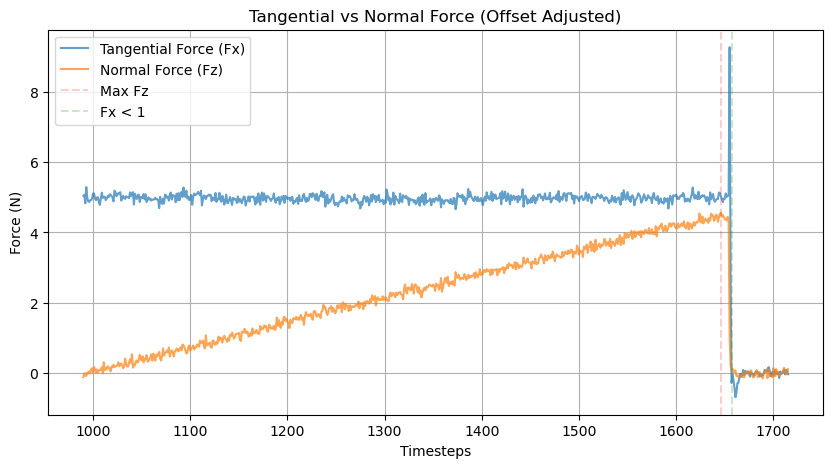

In [3]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_40_5N//log_202405241454.csv"
df = pd.read_csv(data)
test_1, end_1 = plot_forces(df, cut_1=990, cut_2=None, avg_end=1657, offset_position='end', offset_length=15)

<font size="6">Test 2: (worked)</font>

Length from cut_1 to avg_end: 610
Average Fx in the averaging interval [830:1440]: 5.263453701285065
Average Fz in the averaging interval [830:1440]: 1.597819443999744
Maximum Fz in the plotting interval [830:None]: 3.247509765625 at timestep 1420
Time step where Fx drops below 1: 1440


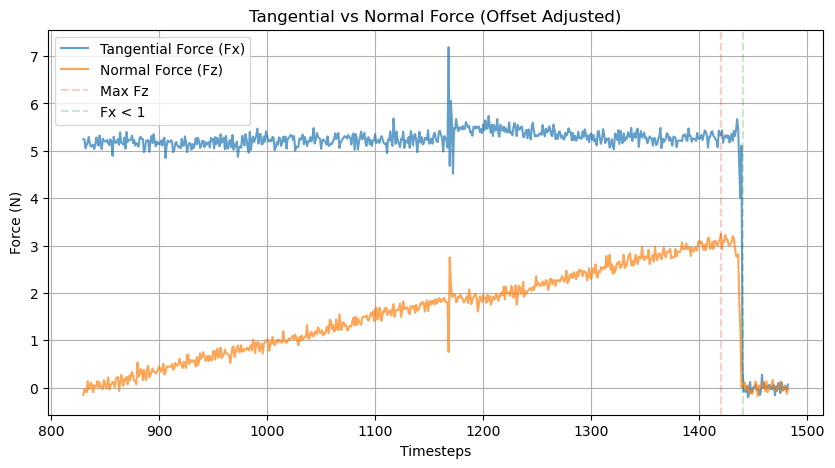

In [4]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_40_5N//log_202405241455.csv"
df = pd.read_csv(data)
test_2, end_2 = plot_forces(df, cut_1=830, cut_2=None, avg_end=1440, offset_position='end', offset_length=15)

<font size="6">Test 3: (worked)</font>

Length from cut_1 to avg_end: 492
Average Fx in the averaging interval [820:1312]: 5.103750424268769
Average Fz in the averaging interval [820:1312]: 1.5246961143927844
Maximum Fz in the plotting interval [820:None]: 3.247119140625 at timestep 1300
Time step where Fx drops below 1: 1312


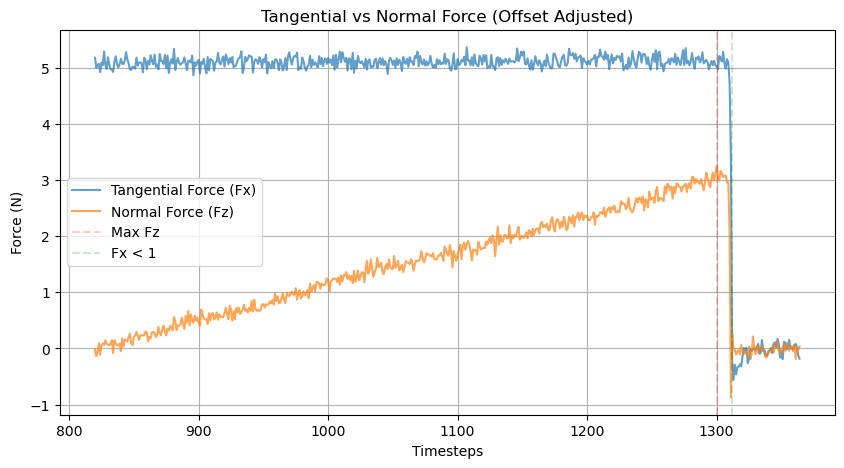

In [5]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_40_5N//log_202405241457.csv"
df = pd.read_csv(data)
test_3, end_3 = plot_forces(df, cut_1=820, cut_2=None, avg_end=1312, offset_position='end', offset_length=15)

<font size="6">Test 4: (worked)</font>

Length from cut_1 to avg_end: 1133
Average Fx in the averaging interval [330:1463]: 4.9463273420864144
Average Fz in the averaging interval [330:1463]: 1.8285267510320131
Maximum Fz in the plotting interval [330:None]: 3.7149332682291667 at timestep 1434
Time step where Fx drops below 1: 1463


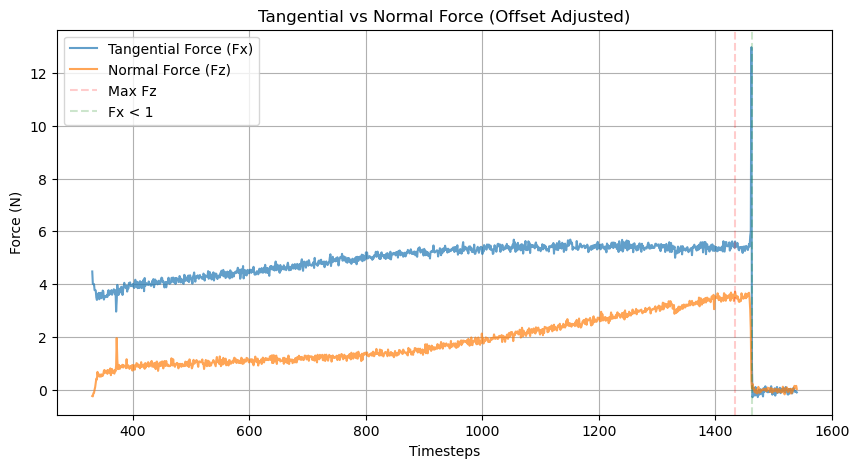

In [6]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_40_5N//log_202405241458.csv"
df = pd.read_csv(data)
test_4, end_4 = plot_forces(df, cut_1=330, cut_2=None, avg_end=1463, offset_position='beginning', offset_length=15)

<font size="6">Test 5: (worked)</font>

Length from cut_1 to avg_end: 1233
Average Fx in the averaging interval [740:1973]: 5.282677672417881
Average Fz in the averaging interval [740:1973]: 3.872061986374062
Maximum Fz in the plotting interval [740:None]: 7.290523274739583 at timestep 1953
Time step where Fx drops below 1: 1973


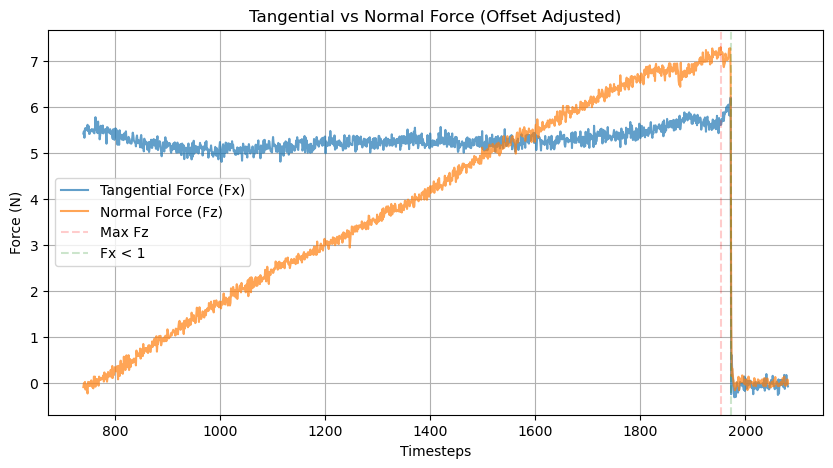

In [7]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_40_5N//log_202405241501.csv"
df = pd.read_csv(data)
test_5, end_5 = plot_forces(df, cut_1=740, cut_2=None, avg_end=1973, offset_position='end', offset_length=15)

<font size="6">Test 6: (worked)</font>

Length from cut_1 to avg_end: 579
Average Fx in the averaging interval [830:1409]: 5.677047407071208
Average Fz in the averaging interval [830:1409]: 1.7333578106446998
Maximum Fz in the plotting interval [830:None]: 2.8256673177083336 at timestep 1367
Time step where Fx drops below 1: 1409


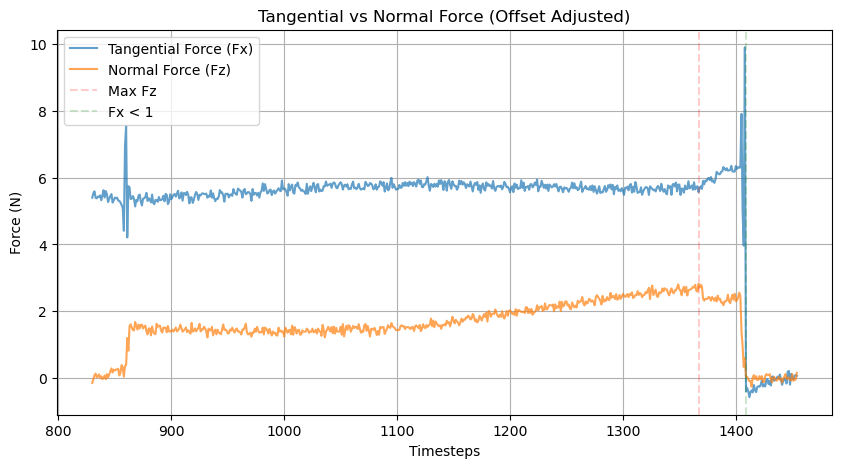

In [8]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_40_5N//log_202405241502.csv"
df = pd.read_csv(data)
test_6, end_6 = plot_forces(df, cut_1=830, cut_2=None, avg_end=1409, offset_position='end', offset_length=15)

<font size="6">Test 7: (worked)</font>

Length from cut_1 to avg_end: 571
Average Fx in the averaging interval [1458:2029]: 5.3026844134333535
Average Fz in the averaging interval [1458:2029]: 1.8130741794138574
Maximum Fz in the plotting interval [1458:None]: 3.51224365234375 at timestep 1999
Time step where Fx drops below 1: 2029


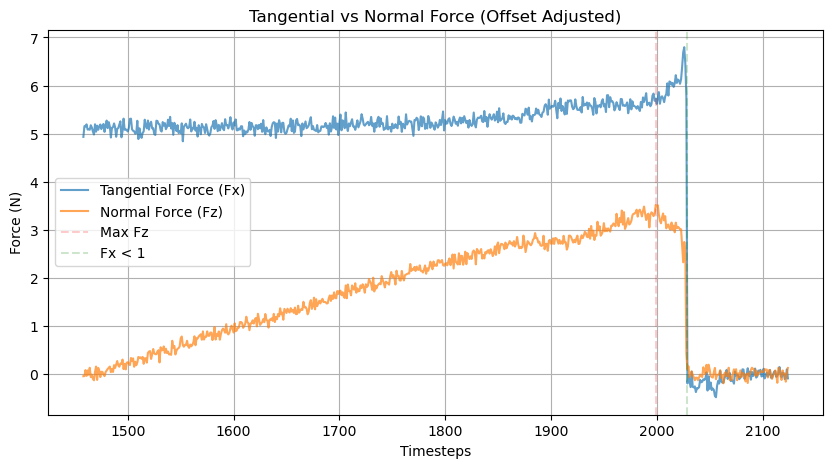

In [9]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_40_5N//log_202405241504.csv"
df = pd.read_csv(data)
test_7, end_7 = plot_forces(df, cut_1=1458, cut_2=None, avg_end=2029, offset_position='end', offset_length=15)

<font size="6">Test 8: (worked)</font>

Length from cut_1 to avg_end: 378
Average Fx in the averaging interval [440:818]: 5.329906322211816
Average Fz in the averaging interval [440:818]: 1.711866558418072
Maximum Fz in the plotting interval [440:None]: 2.5903076171875 at timestep 810
Time step where Fx drops below 1: 818


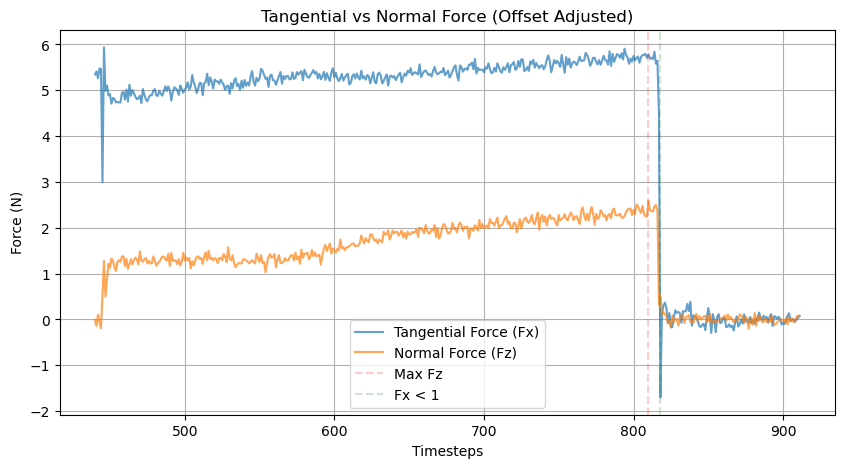

In [10]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_40_5N//log_202405241506.csv"
df = pd.read_csv(data)
test_8, end_8 = plot_forces(df, cut_1=440, cut_2=None, avg_end=818, offset_position='end', offset_length=15)

<font size="6">Test 9: (worked)</font>

Length from cut_1 to avg_end: 1312
Average Fx in the averaging interval [995:2307]: 5.922513065299368
Average Fz in the averaging interval [995:2307]: 4.208031680719639
Maximum Fz in the plotting interval [995:None]: 8.696341959635417 at timestep 2292
Time step where Fx drops below 1: 2307


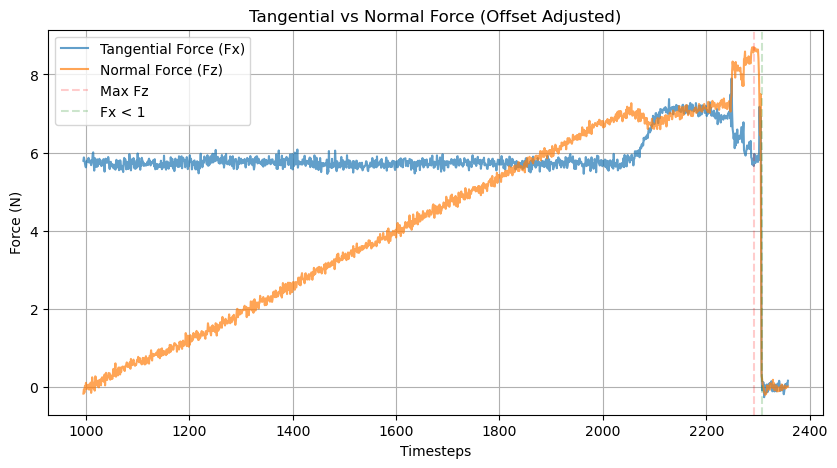

In [11]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_40_5N//log_202405241508.csv"
df = pd.read_csv(data)
test_9, end_9 = plot_forces(df, cut_1=995, cut_2=None, avg_end=2307, offset_position='end', offset_length=15)

<font size="6">Test 10: (worked)</font>

Length from cut_1 to avg_end: 768
Average Fx in the averaging interval [630:1398]: 5.719373761117458
Average Fz in the averaging interval [630:1398]: 1.5641884962717691
Maximum Fz in the plotting interval [630:None]: 4.984806315104167 at timestep 1398
Time step where Fx drops below 1: 1398


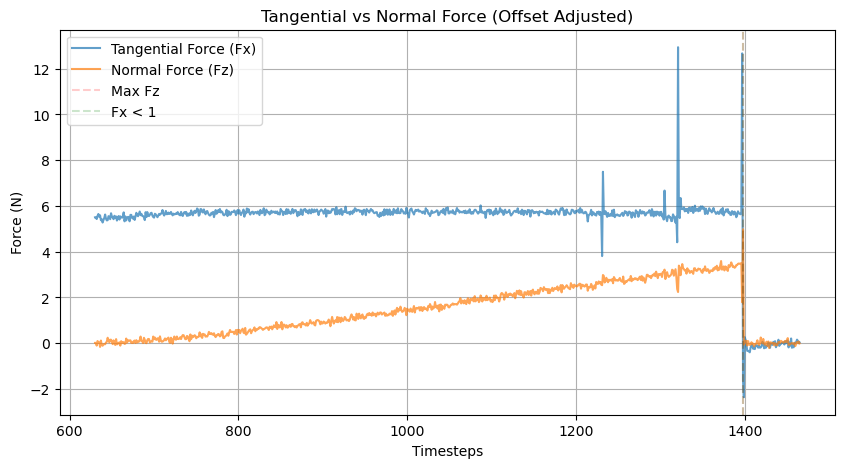

In [12]:
data = "../raw_data/Gripper Test Microspines Angles//Kalkstein_40_5N//log_202405241509.csv"
df = pd.read_csv(data)
test_10, end_10 = plot_forces(df, cut_1=630, cut_2=None, avg_end=1398, offset_position='end', offset_length=15)

In [13]:
def plot_multiple_tests(tests, ends):
    # Find the maximum length among all datasets
    max_length = max([end for end in ends if end is not None])
    
    plt.figure(figsize=(15, 7))
    
    for i, (test, end) in enumerate(zip(tests, ends)):
        if end is not None:
            fz_series = test['Fz']
            fz_series_cut = fz_series[:end]
            if len(fz_series_cut) < max_length:
                padded_fz = np.pad(fz_series_cut.values, (0, max_length - len(fz_series_cut)), 'constant', constant_values=np.nan)
            else:
                padded_fz = fz_series_cut.values
            plt.plot(padded_fz, label=f'Dataset {i+1} Fz', alpha=0.6)
        
    plt.xlabel('Adjusted Timesteps')
    plt.ylabel('Normal Force (Fz) (N)')
    plt.legend()
    plt.title('Normal Force (Fz) of Multiple Datasets')
    plt.grid()
    plt.show()

In [17]:
def calculate_statistics(tests, ends):
    max_fz_values = []
    avg_fz_values = []
    avg_fx_values = []
    
    for test, end in zip(tests, ends):
        if end is not None:
            fz_series = test['Fz']
            fx_series = test['Fx']
            fz_series_cut = fz_series[:end]
            fx_series_cut = fx_series[:end]
            max_fz_values.append(fz_series_cut.max())
            avg_fz_values.append(fz_series_cut.mean())
            avg_fx_values.append(fx_series_cut.mean())
    
    average_max_fz = np.mean(max_fz_values)
    std_max_fz = np.std(max_fz_values)
    
    average_avg_fz = np.mean(avg_fz_values)
    std_avg_fz = np.std(avg_fz_values)
    
    average_avg_fx = np.mean(avg_fx_values)
    std_avg_fx = np.std(avg_fx_values)
    
    print(f"Average of maximum Fz forces: {average_max_fz}")
    print(f"Standard deviation of maximum Fz forces: {std_max_fz}")
    print(f"Average of average Fz forces: {average_avg_fz}")
    print(f"Standard deviation of average Fz forces: {std_avg_fz}")
    print(f"Average of average Fx forces: {average_avg_fx}")
    print(f"Standard deviation of average Fx forces: {std_avg_fx}")
    
    # Create a dictionary to store the statistics
    statistics_dict = {
        'Statistic': ['Average Max Fz', 'Std Max Fz', 'Average Avg Fz', 'Std Avg Fz', 'Average Avg Fx', 'Std Avg Fx'],
        'Value': [average_max_fz, std_max_fz, average_avg_fz, std_avg_fz, average_avg_fx, std_avg_fx]
    }
    
    # Convert the dictionary to a DataFrame
    statistics_df = pd.DataFrame(statistics_dict)
    
    # Save the statistics to a CSV file
    statistics_df.to_csv("../raw_data/Gripper Test Microspines Angles//40//Kalkstein_40_stats.csv", index=False)

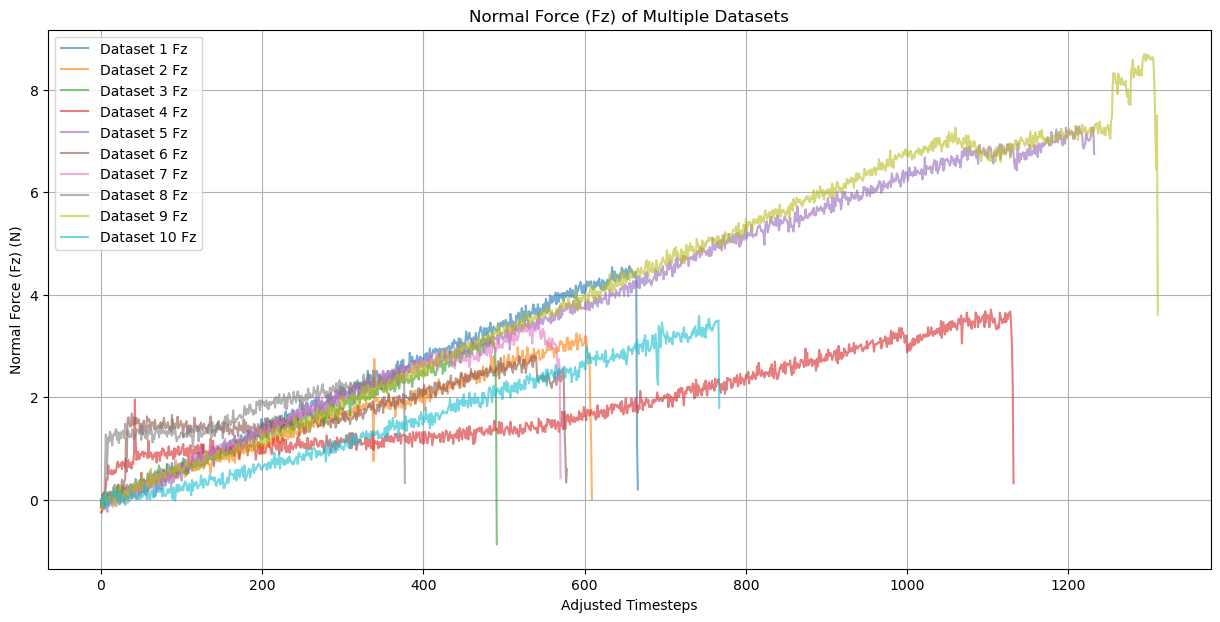

Average of maximum Fz forces: 4.327568359375
Standard deviation of maximum Fz forces: 1.9264190069419738
Average of average Fz forces: 2.2120950667258095
Standard deviation of average Fz forces: 0.9379604898822125
Average of average Fx forces: 5.352507772669686
Standard deviation of average Fx forces: 0.307934023536721


In [18]:
tests = [test_1, test_2, test_3, test_4, test_5, test_6, test_7, test_8, test_9, test_10]
ends = [end_1, end_2, end_3, end_4, end_5, end_6, end_7, end_8, end_9, end_10]
plot_multiple_tests(tests, ends)
calculate_statistics(tests, ends)

In [19]:
def save_tests_to_csv_cut(tests, ends, file_prefix="../raw_data/Gripper Test Microspines Angles//40//Kalkstein_40"):
    # Save each test dataset to a separate CSV file, cutting at the end point
    for i, (test, end) in enumerate(zip(tests, ends)):
        test_cut = test.iloc[:end] if end is not None else test  # Cut the test data at the end point
        test_cut.to_csv(f'{file_prefix}_{i+1}.csv', index=False)

save_tests_to_csv_cut(tests, ends)